In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# Reproducibility and display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Setup complete.")
print("Working directory:", Path.cwd())

Setup complete.
Working directory: c:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026\dashboard_notebooks


In [2]:
# The notebook is in dashboard_notebooks, so the parent is the repo root
PROJECT_ROOT = Path.cwd().parent

print("Project root:", PROJECT_ROOT)
print("Loader exists:", (PROJECT_ROOT / "processing_data" / "loading.py").exists())
print("Raw data folder exists:", (PROJECT_ROOT / "raw_data").exists())

Project root: c:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026
Loader exists: True
Raw data folder exists: True


In [3]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from processing_data.loading import load_flood_masks, load_rainfall_runoff

print("Project data loaders imported successfully.")

Project data loaders imported successfully.


In [4]:
import os

# Change the working directory to the repository root
os.chdir(PROJECT_ROOT)

print("Working directory:", Path.cwd())
print(
    "Flood data folder exists:",
    Path("raw_data/flood_masks/compact_recurring").exists()
)

Working directory: c:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026
Flood data folder exists: True


In [5]:
# Select the exploratory year
YEAR = 2020

# Load flood detections
flood_2020 = load_flood_masks(np.array([YEAR]))

# Load daily ERA5 precipitation and runoff
weather_2020 = load_rainfall_runoff(np.array([YEAR]))

print("Flood data shape:", flood_2020.shape)
print("Weather data dimensions:", weather_2020.sizes)

print("\nFlood columns:")
print(flood_2020.columns.tolist())

print("\nWeather variables:")
print(list(weather_2020.data_vars))

Daily total precipitation and runoff from ERA5 reanalysis loaded from dates 2020-01-01 to 2020-12-31
<xarray.Dataset> Size: 24MB
Dimensions:     (valid_time: 366, latitude: 145, longitude: 57)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2020-01-01 ... 2020-12-31
  * latitude    (latitude) float64 1kB 33.0 32.75 32.5 32.25 ... -2.5 -2.75 -3.0
  * longitude   (longitude) float64 456B 23.0 23.25 23.5 ... 36.5 36.75 37.0
    number      int64 8B 0
Data variables:
    tp          (valid_time, latitude, longitude) float32 12MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
    ro          (valid_time, latitude, longitude) float32 12MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:    

In [6]:
# Convert the ERA5 dataset into a daily DataFrame
weather_df = weather_2020[["tp", "ro"]].to_dataframe().reset_index()

# Rename columns for readability
weather_df = weather_df.rename(columns={
    "valid_time": "date",
    "latitude": "lat",
    "longitude": "lon",
    "tp": "precipitation_m",
    "ro": "runoff_m"
})

print(weather_df.head())
print("\nRows:", len(weather_df))
print("Date range:", weather_df["date"].min(), "to", weather_df["date"].max())

        date   lat    lon  precipitation_m  runoff_m  number
0 2020-01-01  33.0  23.00         0.008402       0.0       0
1 2020-01-01  33.0  23.25         0.004798       0.0       0
2 2020-01-01  33.0  23.50         0.002825       0.0       0
3 2020-01-01  33.0  23.75         0.001849       0.0       0
4 2020-01-01  33.0  24.00         0.001067       0.0       0

Rows: 3024990
Date range: 2020-01-01 00:00:00 to 2020-12-31 00:00:00


In [7]:
import geopandas as gpd

admin2_path = PROJECT_ROOT / "raw_data" / "Administrative boundaries" / "ssd_admin2.geojson"

admin2 = gpd.read_file(admin2_path)

print("Columns:")
print(admin2.columns.tolist())

print("\nAreas matching Ayod:")
print(
    admin2[
        admin2["adm2_name"].str.contains("Ayod", case=False, na=False)
    ][["adm2_name", "geometry"]]
)

Columns:
['adm2_name', 'adm2_name1', 'adm2_name2', 'adm2_name3', 'adm2_pcode', 'adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode', 'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode', 'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang', 'lang1', 'lang2', 'lang3', 'adm2_ref_name', 'center_lat', 'center_lon', 'geometry']

Areas matching Ayod:
   adm2_name                                           geometry
15      Ayod  POLYGON ((31.49438 8.57321, 31.50677 8.61376, ...


In [9]:

import geopandas as gpd
from shapely.geometry import box

# Select Ayod's boundary
ayod = admin2.loc[admin2["adm2_name"] == "Ayod"].copy()
assert len(ayod) == 1, "Expected exactly one Ayod polygon."

area_crs = "EPSG:6933"
ayod_projected = ayod.to_crs(area_crs)
ayod_geom = ayod_projected.geometry.iloc[0]

# Get unique ERA5 grid-cell centres
grid_centres = weather_df[["lat", "lon"]].drop_duplicates()

# Build 0.25-degree grid-cell squares directly.
# This avoids using buffer() in a geographic CRS.
half_step = 0.125

grid_cells = gpd.GeoDataFrame(
    grid_centres.copy(),
    geometry=[
        box(lon - half_step, lat - half_step,
            lon + half_step, lat + half_step)
        for lat, lon in zip(grid_centres["lat"], grid_centres["lon"])
    ],
    crs="EPSG:4326"
)

# Project cells before calculating intersection areas
grid_cells = grid_cells.to_crs(area_crs)

grid_cells["intersection_area"] = (
    grid_cells.geometry.intersection(ayod_geom).area
)

ayod_weights = grid_cells.loc[
    grid_cells["intersection_area"] > 0,
    ["lat", "lon", "intersection_area"]
].copy()

ayod_weights["weight"] = (
    ayod_weights["intersection_area"]
    / ayod_weights["intersection_area"].sum()
)

print("Grid cells intersecting Ayod:", len(ayod_weights))
print("Sum of weights:", ayod_weights["weight"].sum())
print("Ayod area (km²):", ayod_projected.geometry.area.iloc[0] / 1e6)


Grid cells intersecting Ayod: 29
Sum of weights: 0.9999999999999999
Ayod area (km²): 13449.146530494223


In [10]:
# Attach Ayod's spatial weights to the daily ERA5 data
ayod_weather_df = weather_df.merge(
    ayod_weights[["lat", "lon", "weight"]],
    on=["lat", "lon"],
    how="inner",
    validate="many_to_one"
)

# Calculate weighted rainfall and runoff for each day
ayod_weather_df["precipitation_weighted"] = (
    ayod_weather_df["precipitation_m"] * ayod_weather_df["weight"]
)
ayod_weather_df["runoff_weighted"] = (
    ayod_weather_df["runoff_m"] * ayod_weather_df["weight"]
)

ayod_weather = (
    ayod_weather_df
    .groupby("date")[["precipitation_weighted", "runoff_weighted"]]
    .sum()
    .rename(columns={
        "precipitation_weighted": "precipitation_m",
        "runoff_weighted": "runoff_m"
    })
    .sort_index()
)

# Convert daily depths from metres to millimetres
ayod_weather["precipitation_mm"] = ayod_weather["precipitation_m"] * 1000
ayod_weather["runoff_mm"] = ayod_weather["runoff_m"] * 1000

# Calculate antecedent 3-, 7-, and 14-day totals
for window in [3, 7, 14]:
    ayod_weather[f"precipitation_{window}d_mm"] = (
        ayod_weather["precipitation_mm"]
        .rolling(window=window, min_periods=window)
        .sum()
    )
    ayod_weather[f"runoff_{window}d_mm"] = (
        ayod_weather["runoff_mm"]
        .rolling(window=window, min_periods=window)
        .sum()
    )

print("Ayod weather shape:", ayod_weather.shape)
print("Date range:", ayod_weather.index.min(), "to", ayod_weather.index.max())
display(ayod_weather.head(16).round(3))


Ayod weather shape: (366, 10)
Date range: 2020-01-01 00:00:00 to 2020-12-31 00:00:00


,precipitation_m,runoff_m,precipitation_mm,runoff_mm,precipitation_3d_mm,runoff_3d_mm,precipitation_7d_mm,runoff_7d_mm,precipitation_14d_mm,runoff_14d_mm
date,,,,,,,,,,
2020-01-01,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2020-01-04,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2020-01-06,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2020-01-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2020-01-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2020-01-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


,count,mean,std,min,50%,75%,90%,95%,99%,max
precipitation_mm,366.0,2.238,4.551,0.0,0.204,2.237,7.521,11.181,20.664,40.337
runoff_mm,366.0,0.116,0.407,0.0,0.001,0.021,0.191,0.564,2.096,3.321



Days with rainfall > 0: 241
Days with runoff > 0: 216

Days with the highest rainfall:


,precipitation_mm,runoff_mm
date,,
2020-06-09,40.337,2.152
2020-07-28,26.229,1.844
2020-08-08,22.718,3.321
2020-05-22,21.123,0.659
2020-09-06,20.417,2.889
2020-08-29,19.318,2.066
2020-10-03,18.692,1.864
2020-07-19,17.263,1.876
2020-08-16,15.912,3.030


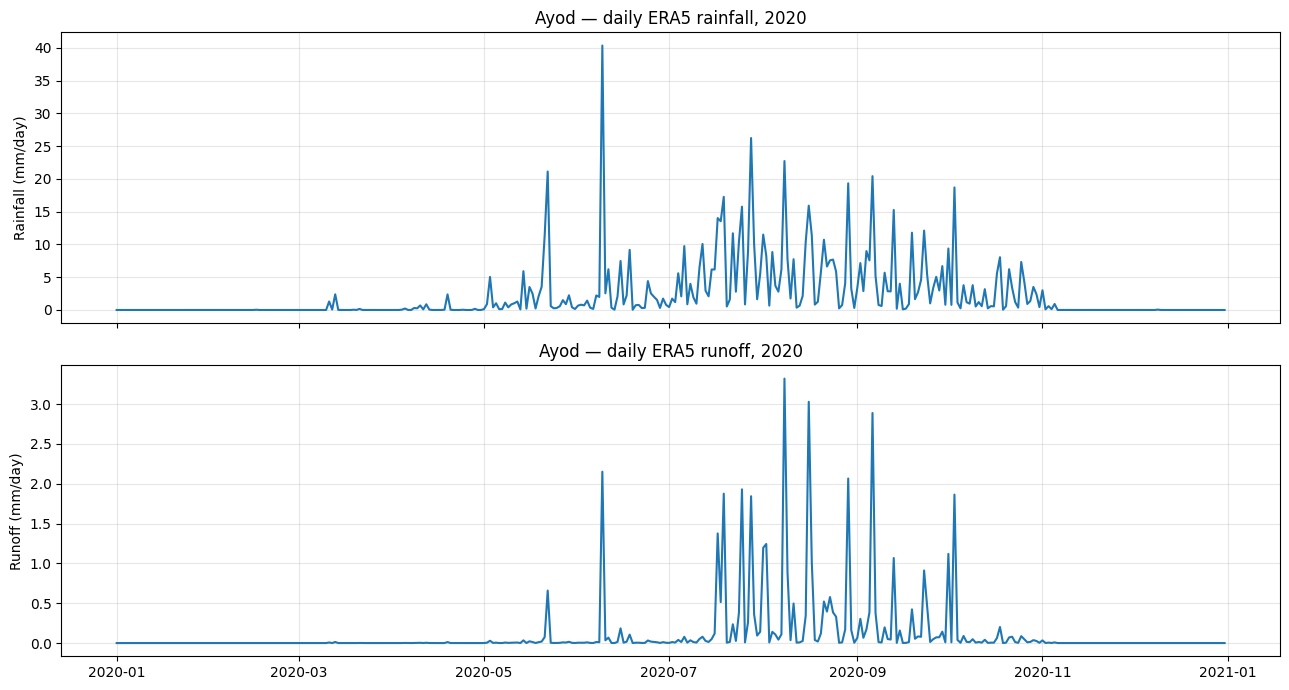

In [11]:
# Summarise rainfall and runoff across the full year
weather_summary = ayod_weather[
    ["precipitation_mm", "runoff_mm"]
].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T

display(weather_summary.round(3))

print(
    "\nDays with rainfall > 0:",
    int((ayod_weather["precipitation_mm"] > 0).sum())
)
print(
    "Days with runoff > 0:",
    int((ayod_weather["runoff_mm"] > 0).sum())
)

print("\nDays with the highest rainfall:")
display(
    ayod_weather.nlargest(10, "precipitation_mm")[
        ["precipitation_mm", "runoff_mm"]
    ].round(3)
)

# Plot daily rainfall and runoff
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(
    ayod_weather.index,
    ayod_weather["precipitation_mm"]
)
axes[0].set_ylabel("Rainfall (mm/day)")
axes[0].set_title("Ayod — daily ERA5 rainfall, 2020")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    ayod_weather.index,
    ayod_weather["runoff_mm"]
)
axes[1].set_ylabel("Runoff (mm/day)")
axes[1].set_title("Ayod — daily ERA5 runoff, 2020")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [12]:
# Get the Ayod polygon and its bounding box
ayod_geom = ayod.geometry.iloc[0]
minx, miny, maxx, maxy = ayod.total_bounds

# Filter to unusual flood detections near Ayod
unusual = flood_2020.loc[flood_2020["flood_type"] == 1].copy()

unusual_near_ayod = unusual.loc[
    unusual["lon"].between(minx, maxx)
    & unusual["lat"].between(miny, maxy)
].copy()

print("All unusual detections:", len(unusual))
print("Unusual detections within Ayod bounding box:", len(unusual_near_ayod))

# Keep only detections inside Ayod's actual boundary
unusual_points = gpd.GeoDataFrame(
    unusual_near_ayod,
    geometry=gpd.points_from_xy(
        unusual_near_ayod["lon"],
        unusual_near_ayod["lat"]
    ),
    crs="EPSG:4326"
)

ayod_unusual_points = gpd.sjoin(
    unusual_points,
    ayod[["adm2_name", "geometry"]],
    how="inner",
    predicate="within"
)

# Count detections per day
ayod_unusual_daily = (
    ayod_unusual_points
    .groupby("date")
    .size()
    .rename("unusual_detections")
    .to_frame()
)

ayod_unusual_daily.index = pd.to_datetime(ayod_unusual_daily.index)
ayod_unusual_daily.index.name = "date"

print("Dates with unusual detections in Ayod:", len(ayod_unusual_daily))
print("Total unusual detections in Ayod:", int(ayod_unusual_daily["unusual_detections"].sum()))

display(ayod_unusual_daily.sort_values("unusual_detections", ascending=False).head(10))


All unusual detections: 3105516
Unusual detections within Ayod bounding box: 51822
Dates with unusual detections in Ayod: 248
Total unusual detections in Ayod: 47803


,unusual_detections
date,
2020-12-31,2080
2020-12-26,1396
2020-12-29,1369
2020-12-15,1359
2020-12-17,1303
2020-03-27,1294
2020-03-07,1282
2020-12-28,1275
2020-10-12,1252


In [13]:
# Start with the full daily weather series
lag_data = ayod_weather.copy()
lag_data.index = pd.to_datetime(lag_data.index)

# Add daily unusual flood detections
flood_daily = ayod_unusual_daily["unusual_detections"].copy()
flood_daily.index = pd.to_datetime(flood_daily.index)

lag_data = lag_data.join(flood_daily, how="left")

# Zero here means no unusual detection was recorded in Ayod that day.
# It does NOT guarantee that no flooding occurred.
lag_data["unusual_detections"] = (
    lag_data["unusual_detections"].fillna(0).astype(int)
)

# Create a log-transformed outcome to reduce the influence of very large counts
lag_data["log_unusual_detections"] = np.log1p(
    lag_data["unusual_detections"]
)

print("Rows:", len(lag_data))
print("Date range:", lag_data.index.min(), "to", lag_data.index.max())
print("Days with unusual detections:", (lag_data["unusual_detections"] > 0).sum())
print("Total unusual detections:", lag_data["unusual_detections"].sum())

display(
    lag_data.loc[
        lag_data["unusual_detections"] > 0,
        ["unusual_detections", "precipitation_mm", "runoff_mm"]
    ]
    .sort_values("unusual_detections", ascending=False)
    .head(10)
)


Rows: 366
Date range: 2020-01-01 00:00:00 to 2020-12-31 00:00:00
Days with unusual detections: 248
Total unusual detections: 47803


,unusual_detections,precipitation_mm,runoff_mm
date,,,
2020-12-31,2080,0.000000,0.000000
2020-12-26,1396,0.000000,0.000000
2020-12-29,1369,0.000000,0.000000
2020-12-15,1359,0.000000,0.000000
2020-12-17,1303,0.000000,0.000000
2020-03-27,1294,0.000000,0.000000
2020-03-07,1282,0.014761,0.000007
2020-12-28,1275,0.000000,0.000000
2020-10-12,1252,0.578566,0.005566


In [14]:

# Test weather totals ending 0–14 days before each flood-detection date
lag_results = []

for variable in ["precipitation", "runoff"]:
    for window in [3, 7, 14]:
        weather_col = f"{variable}_{window}d_mm"

        for lag in range(0, 15):
            shifted_weather = lag_data[weather_col].shift(lag)

            valid = (
                shifted_weather.notna()
                & lag_data["log_unusual_detections"].notna()
            )

            correlation = (
                lag_data.loc[valid, "log_unusual_detections"]
                .corr(shifted_weather.loc[valid])
            )

            lag_results.append({
                "weather_variable": variable,
                "accumulation_days": window,
                "lag_days": lag,
                "correlation": correlation,
                "n_days": int(valid.sum())
            })

lag_results = pd.DataFrame(lag_results)

display(
    lag_results.sort_values("correlation", ascending=False).head(15)
)


,weather_variable,accumulation_days,lag_days,correlation,n_days
58,runoff,3,13,-0.177335,351
57,runoff,3,12,-0.185863,352
59,runoff,3,14,-0.195469,350
51,runoff,3,6,-0.211409,358
56,runoff,3,11,-0.221763,353
50,runoff,3,5,-0.223742,359
49,runoff,3,4,-0.235098,360
52,runoff,3,7,-0.244021,357
74,runoff,7,14,-0.257041,346
72,runoff,7,12,-0.265933,348


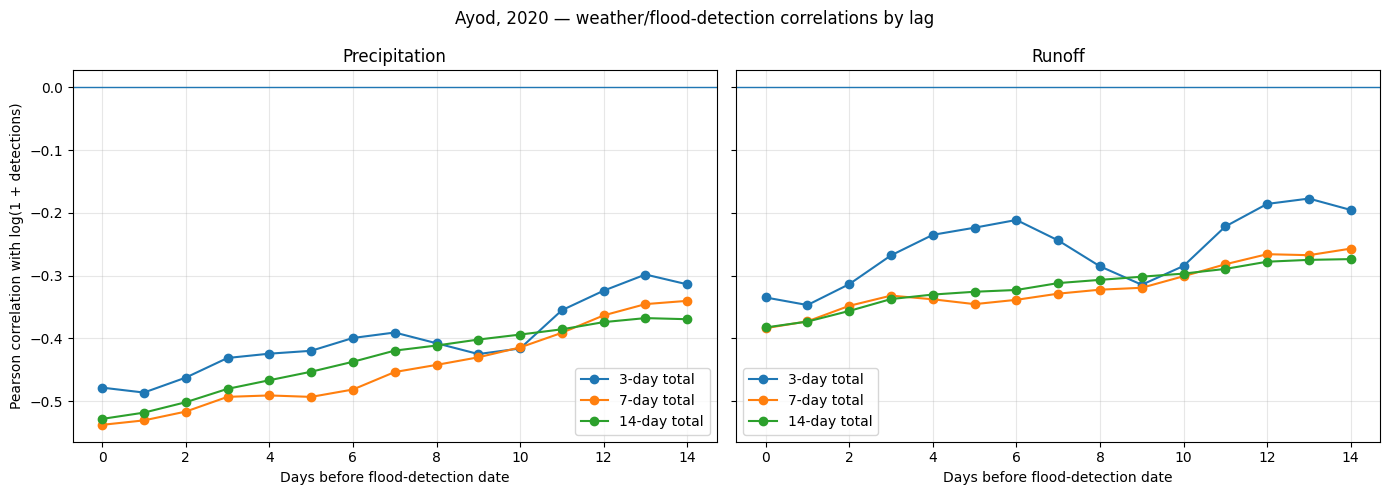

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, variable in zip(axes, ["precipitation", "runoff"]):
    subset = lag_results[lag_results["weather_variable"] == variable]

    for window in [3, 7, 14]:
        series = subset[subset["accumulation_days"] == window]
        ax.plot(
            series["lag_days"],
            series["correlation"],
            marker="o",
            label=f"{window}-day total"
        )

    ax.axhline(0, linewidth=1)
    ax.set_title(variable.capitalize())
    ax.set_xlabel("Days before flood-detection date")
    ax.set_xticks(range(0, 15, 2))
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Pearson correlation with log(1 + detections)")
fig.suptitle("Ayod, 2020 — weather/flood-detection correlations by lag")
plt.tight_layout()
plt.show()


In [16]:
# Define a broad May–October rainy-season period for this exploratory check
rainy_season = lag_data.index.month.isin([5, 6, 7, 8, 9, 10])

seasonal_check = []

for period_name, mask in [
    ("All dates", np.ones(len(lag_data), dtype=bool)),
    ("May–October", rainy_season),
    ("November–April", ~rainy_season)
]:
    for variable in ["precipitation", "runoff"]:
        col = f"{variable}_7d_mm"

        for lag in [0, 3, 7, 10, 14]:
            x = lag_data[col].shift(lag)
            y = lag_data["log_unusual_detections"]

            valid = mask & x.notna() & y.notna()

            seasonal_check.append({
                "period": period_name,
                "weather_variable": variable,
                "lag_days": lag,
                "correlation": x[valid].corr(y[valid]),
                "n_days": int(valid.sum())
            })

seasonal_check = pd.DataFrame(seasonal_check)
display(
    seasonal_check.pivot_table(
        index=["period", "weather_variable"],
        columns="lag_days",
        values="correlation"
    ).round(3)
)


lag_days                            0      3      7      10     14
period         weather_variable                                   
All dates      precipitation    -0.538 -0.493 -0.454 -0.414 -0.340
               runoff           -0.384 -0.332 -0.329 -0.301 -0.257
May–October    precipitation    -0.257 -0.139 -0.080 -0.037  0.086
               runoff           -0.144 -0.033 -0.037  0.009  0.083
November–April precipitation    -0.389 -0.350 -0.246 -0.129 -0.049
               runoff           -0.308 -0.291 -0.227 -0.170 -0.102

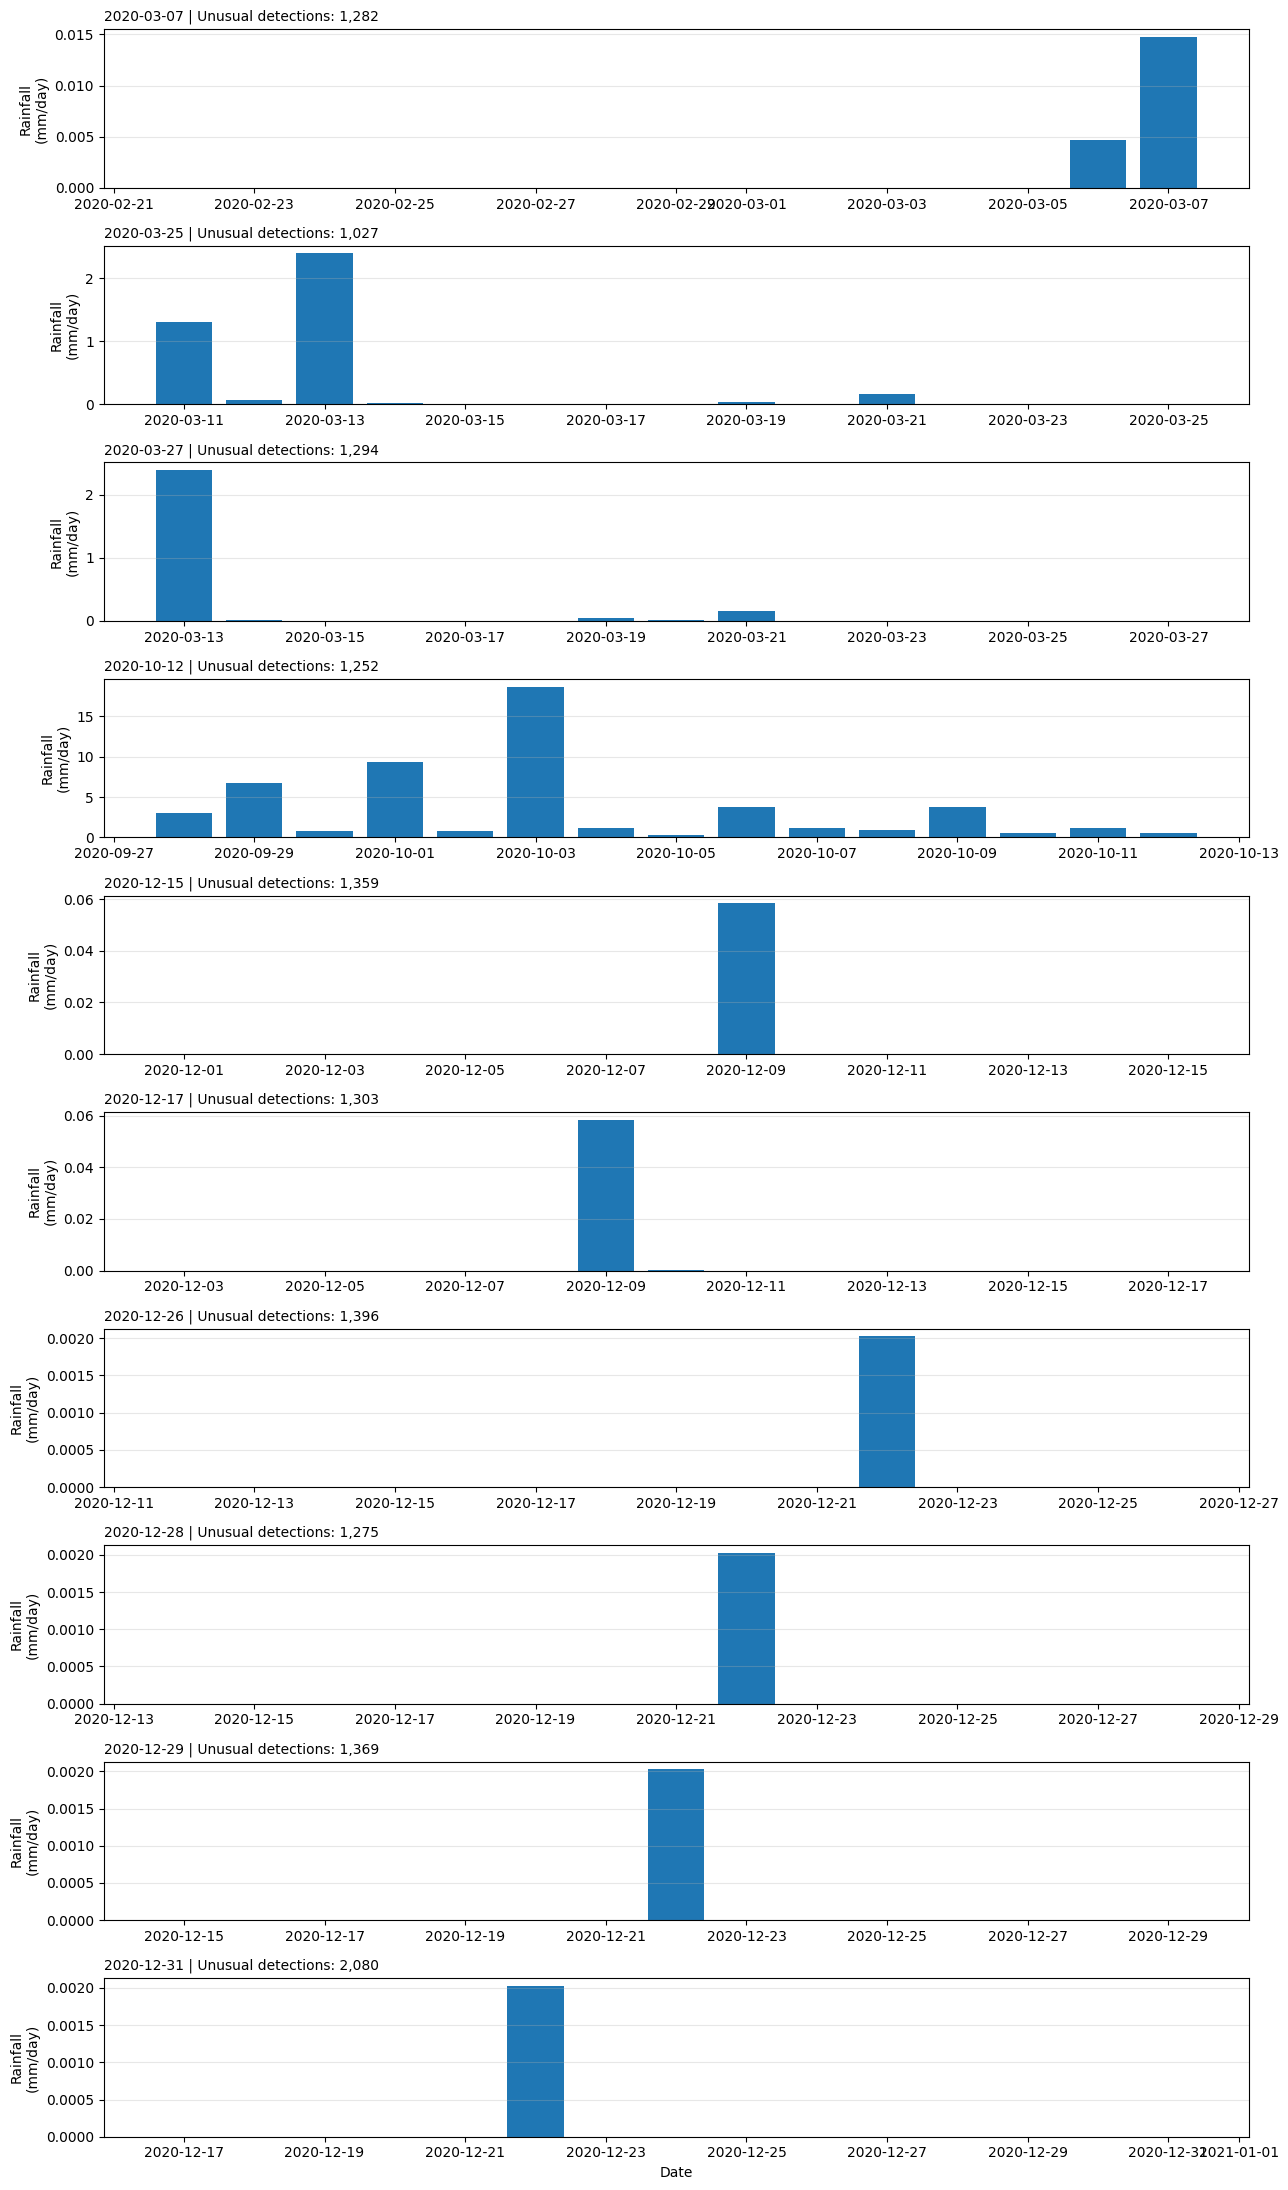

In [18]:
# Select the 10 dates with the highest unusual-detection counts
top_dates = (
    lag_data["unusual_detections"]
    .nlargest(10)
    .sort_index()
    .index
)

fig, axes = plt.subplots(
    len(top_dates), 1,
    figsize=(13, 2.2 * len(top_dates)),
    sharex=False
)

for ax, event_date in zip(axes, top_dates):
    start_date = event_date - pd.Timedelta(days=14)
    event_window = lag_data.loc[start_date:event_date]

    ax.bar(
        event_window.index,
        event_window["precipitation_mm"],
        label="Rainfall (mm/day)"
    )

    ax.set_ylabel("Rainfall\n(mm/day)")
    ax.set_title(
        f"{event_date:%Y-%m-%d} | "
        f"Unusual detections: "
        f"{lag_data.loc[event_date, 'unusual_detections']:,}",
        loc="left",
        fontsize=10
    )
    ax.grid(True, axis="y", alpha=0.3)

plt.xlabel("Date")
plt.tight_layout()
plt.show()


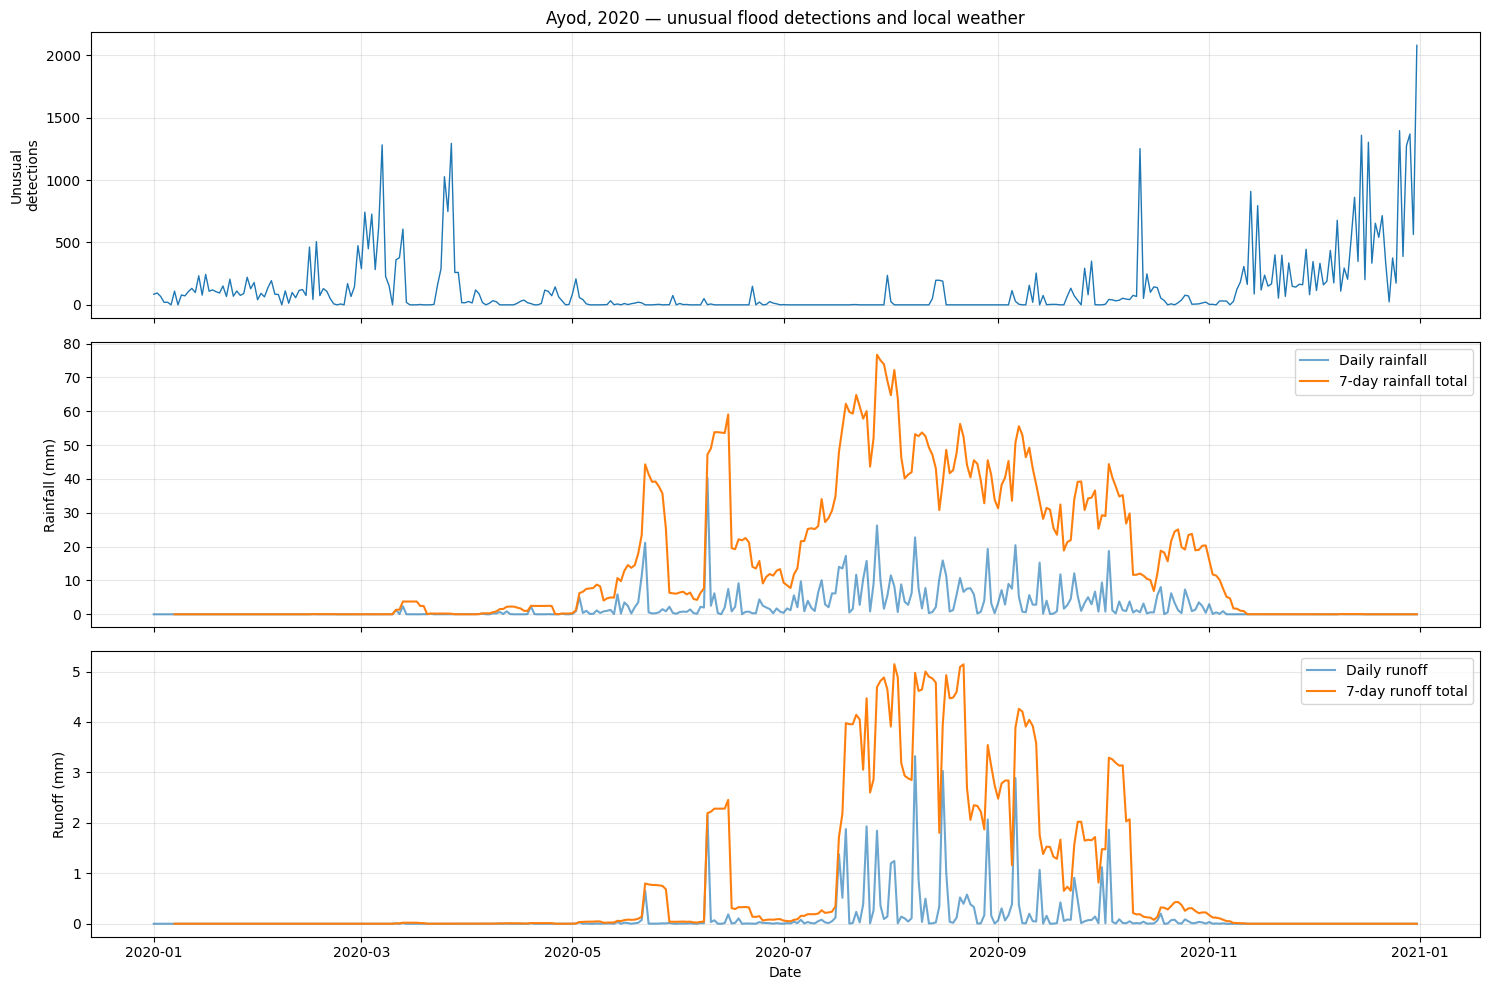

In [20]:
fig, axes = plt.subplots(
    3, 1, figsize=(15, 10), sharex=True
)

# Daily unusual detections
axes[0].plot(
    lag_data.index,
    lag_data["unusual_detections"],
    linewidth=1
)
axes[0].set_ylabel("Unusual\ndetections")
axes[0].set_title("Ayod, 2020 — unusual flood detections and local weather")
axes[0].grid(True, alpha=0.3)

# Daily rainfall and 7-day accumulation
axes[1].plot(
    lag_data.index,
    lag_data["precipitation_mm"],
    alpha=0.65,
    label="Daily rainfall"
)
axes[1].plot(
    lag_data.index,
    lag_data["precipitation_7d_mm"],
    label="7-day rainfall total"
)
axes[1].set_ylabel("Rainfall (mm)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Daily runoff and 7-day accumulation
axes[2].plot(
    lag_data.index,
    lag_data["runoff_mm"],
    alpha=0.65,
    label="Daily runoff"
)
axes[2].plot(
    lag_data.index,
    lag_data["runoff_7d_mm"],
    label="7-day runoff total"
)
axes[2].set_ylabel("Runoff (mm)")
axes[2].set_xlabel("Date")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [21]:
def monthly_summary_for_year(year):
    """Create exploratory monthly weather and unusual-detection summaries for Ayod."""

    # --- Load data ---
    flood = load_flood_masks(np.array([year]))
    weather = load_rainfall_runoff(np.array([year]))

    # --- Aggregate ERA5 weather over Ayod using existing spatial weights ---
    weather_df_year = (
        weather[["tp", "ro"]]
        .to_dataframe()
        .reset_index()
        .rename(columns={
            "valid_time": "date",
            "latitude": "lat",
            "longitude": "lon",
            "tp": "precipitation_m",
            "ro": "runoff_m"
        })
    )

    weather_df_year["date"] = pd.to_datetime(weather_df_year["date"])

    weighted = weather_df_year.merge(
        ayod_weights[["lat", "lon", "weight"]],
        on=["lat", "lon"],
        how="inner",
        validate="many_to_one"
    )

    weighted["precipitation_mm"] = weighted["precipitation_m"] * 1000
    weighted["runoff_mm"] = weighted["runoff_m"] * 1000

    weighted["weighted_precipitation_mm"] = (
        weighted["precipitation_mm"] * weighted["weight"]
    )
    weighted["weighted_runoff_mm"] = (
        weighted["runoff_mm"] * weighted["weight"]
    )

    daily_weather = (
        weighted.groupby("date")[
            ["weighted_precipitation_mm", "weighted_runoff_mm"]
        ]
        .sum()
        .rename(columns={
            "weighted_precipitation_mm": "rainfall_mm",
            "weighted_runoff_mm": "runoff_mm"
        })
    )

    # --- Restrict flood detections to Ayod's bounding box first ---
    unusual = flood.loc[flood["flood_type"] == 1].copy()
    minx, miny, maxx, maxy = ayod.total_bounds

    unusual = unusual.loc[
        unusual["lon"].between(minx, maxx)
        & unusual["lat"].between(miny, maxy)
    ].copy()

    points = gpd.GeoDataFrame(
        unusual,
        geometry=gpd.points_from_xy(unusual["lon"], unusual["lat"]),
        crs="EPSG:4326"
    )

    inside_ayod = gpd.sjoin(
        points,
        ayod[["adm2_name", "geometry"]],
        how="inner",
        predicate="within"
    )

    inside_ayod["date"] = pd.to_datetime(inside_ayod["date"])

    daily_flood = (
        inside_ayod.groupby("date")
        .size()
        .rename("unusual_detections")
    )

    # --- Combine and summarise monthly ---
    daily = daily_weather.join(daily_flood, how="left")
    daily["unusual_detections"] = (
        daily["unusual_detections"].fillna(0).astype(int)
    )

    daily["month"] = daily.index.month

    monthly = daily.groupby("month").agg(
        rainfall_mm=("rainfall_mm", "sum"),
        runoff_mm=("runoff_mm", "sum"),
        mean_daily_rainfall_mm=("rainfall_mm", "mean"),
        mean_daily_runoff_mm=("runoff_mm", "mean"),
        unusual_detections=("unusual_detections", "sum"),
        days_with_detections=("unusual_detections", lambda x: (x > 0).sum())
    )

    monthly["year"] = year
    return daily, monthly


In [22]:
daily_2020_check, monthly_2020_check = monthly_summary_for_year(2020)

display(monthly_2020_check.round(2))

print(
    "\nTotal unusual detections:",
    int(monthly_2020_check["unusual_detections"].sum())
)
print(
    "Total rainfall (sum of daily area-weighted depths, mm):",
    round(monthly_2020_check["rainfall_mm"].sum(), 2)
)


Daily total precipitation and runoff from ERA5 reanalysis loaded from dates 2020-01-01 to 2020-12-31
<xarray.Dataset> Size: 24MB
Dimensions:     (valid_time: 366, latitude: 145, longitude: 57)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2020-01-01 ... 2020-12-31
  * latitude    (latitude) float64 1kB 33.0 32.75 32.5 32.25 ... -2.5 -2.75 -3.0
  * longitude   (longitude) float64 456B 23.0 23.25 23.5 ... 36.5 36.75 37.0
    number      int64 8B 0
Data variables:
    tp          (valid_time, latitude, longitude) float32 12MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
    ro          (valid_time, latitude, longitude) float32 12MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:    

,rainfall_mm,runoff_mm,mean_daily_rainfall_mm,mean_daily_runoff_mm,unusual_detections,days_with_detections,year
month,,,,,,,
1,0.00,0.00,0.00,0.00,3209,29,2020
2,0.04,0.00,0.00,0.00,3498,26,2020
3,4.01,0.02,0.13,0.00,10221,24,2020
4,5.26,0.02,0.18,0.00,998,21,2020
5,69.92,0.94,2.26,0.03,605,21,2020
6,95.10,2.74,3.17,0.09,296,12,2020
7,203.31,9.62,6.56,0.31,242,4,2020
8,197.06,16.82,6.36,0.54,660,5,2020
9,147.10,8.18,4.90,0.27,1701,19,2020



Total unusual detections: 47803
Total rainfall (sum of daily area-weighted depths, mm): 819.26


In [23]:
# Years selected to compare earlier and later parts of the record
YEARS_TO_COMPARE = [2003, 2010, 2015, 2019, 2020, 2023]

daily_by_year = {}
monthly_by_year = {}

for year in YEARS_TO_COMPARE:
    print(f"Processing {year}...")

    daily_year, monthly_year = monthly_summary_for_year(year)

    daily_by_year[year] = daily_year
    monthly_by_year[year] = monthly_year

monthly_all = pd.concat(monthly_by_year.values()).reset_index()

print("\nCompleted.")
print("Years processed:", sorted(monthly_by_year.keys()))
print("Monthly records:", len(monthly_all))

display(
    monthly_all[
        ["year", "month", "rainfall_mm", "runoff_mm",
         "unusual_detections", "days_with_detections"]
    ].head(18).round(2)
)


Processing 2003...
Daily total precipitation and runoff from ERA5 reanalysis loaded from dates 2003-01-01 to 2003-12-31
<xarray.Dataset> Size: 24MB
Dimensions:     (valid_time: 365, latitude: 145, longitude: 57)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2003-01-01 ... 2003-12-31
  * latitude    (latitude) float64 1kB 33.0 32.75 32.5 32.25 ... -2.5 -2.75 -3.0
  * longitude   (longitude) float64 456B 23.0 23.25 23.5 ... 36.5 36.75 37.0
    number      int64 8B 0
Data variables:
    tp          (valid_time, latitude, longitude) float32 12MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
    ro          (valid_time, latitude, longitude) float32 12MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecas

,year,month,rainfall_mm,runoff_mm,unusual_detections,days_with_detections
0,2003,1,0.01,0.00,5339,31
1,2003,2,0.84,0.01,2406,22
2,2003,3,0.58,0.00,822,15
3,2003,4,60.79,0.65,349,21
4,2003,5,86.14,0.88,839,20
5,2003,6,162.03,5.68,67,16
6,2003,7,226.94,16.11,125,10
7,2003,8,250.47,29.27,916,12
8,2003,9,170.46,16.74,668,20
9,2003,10,110.17,5.29,224,20


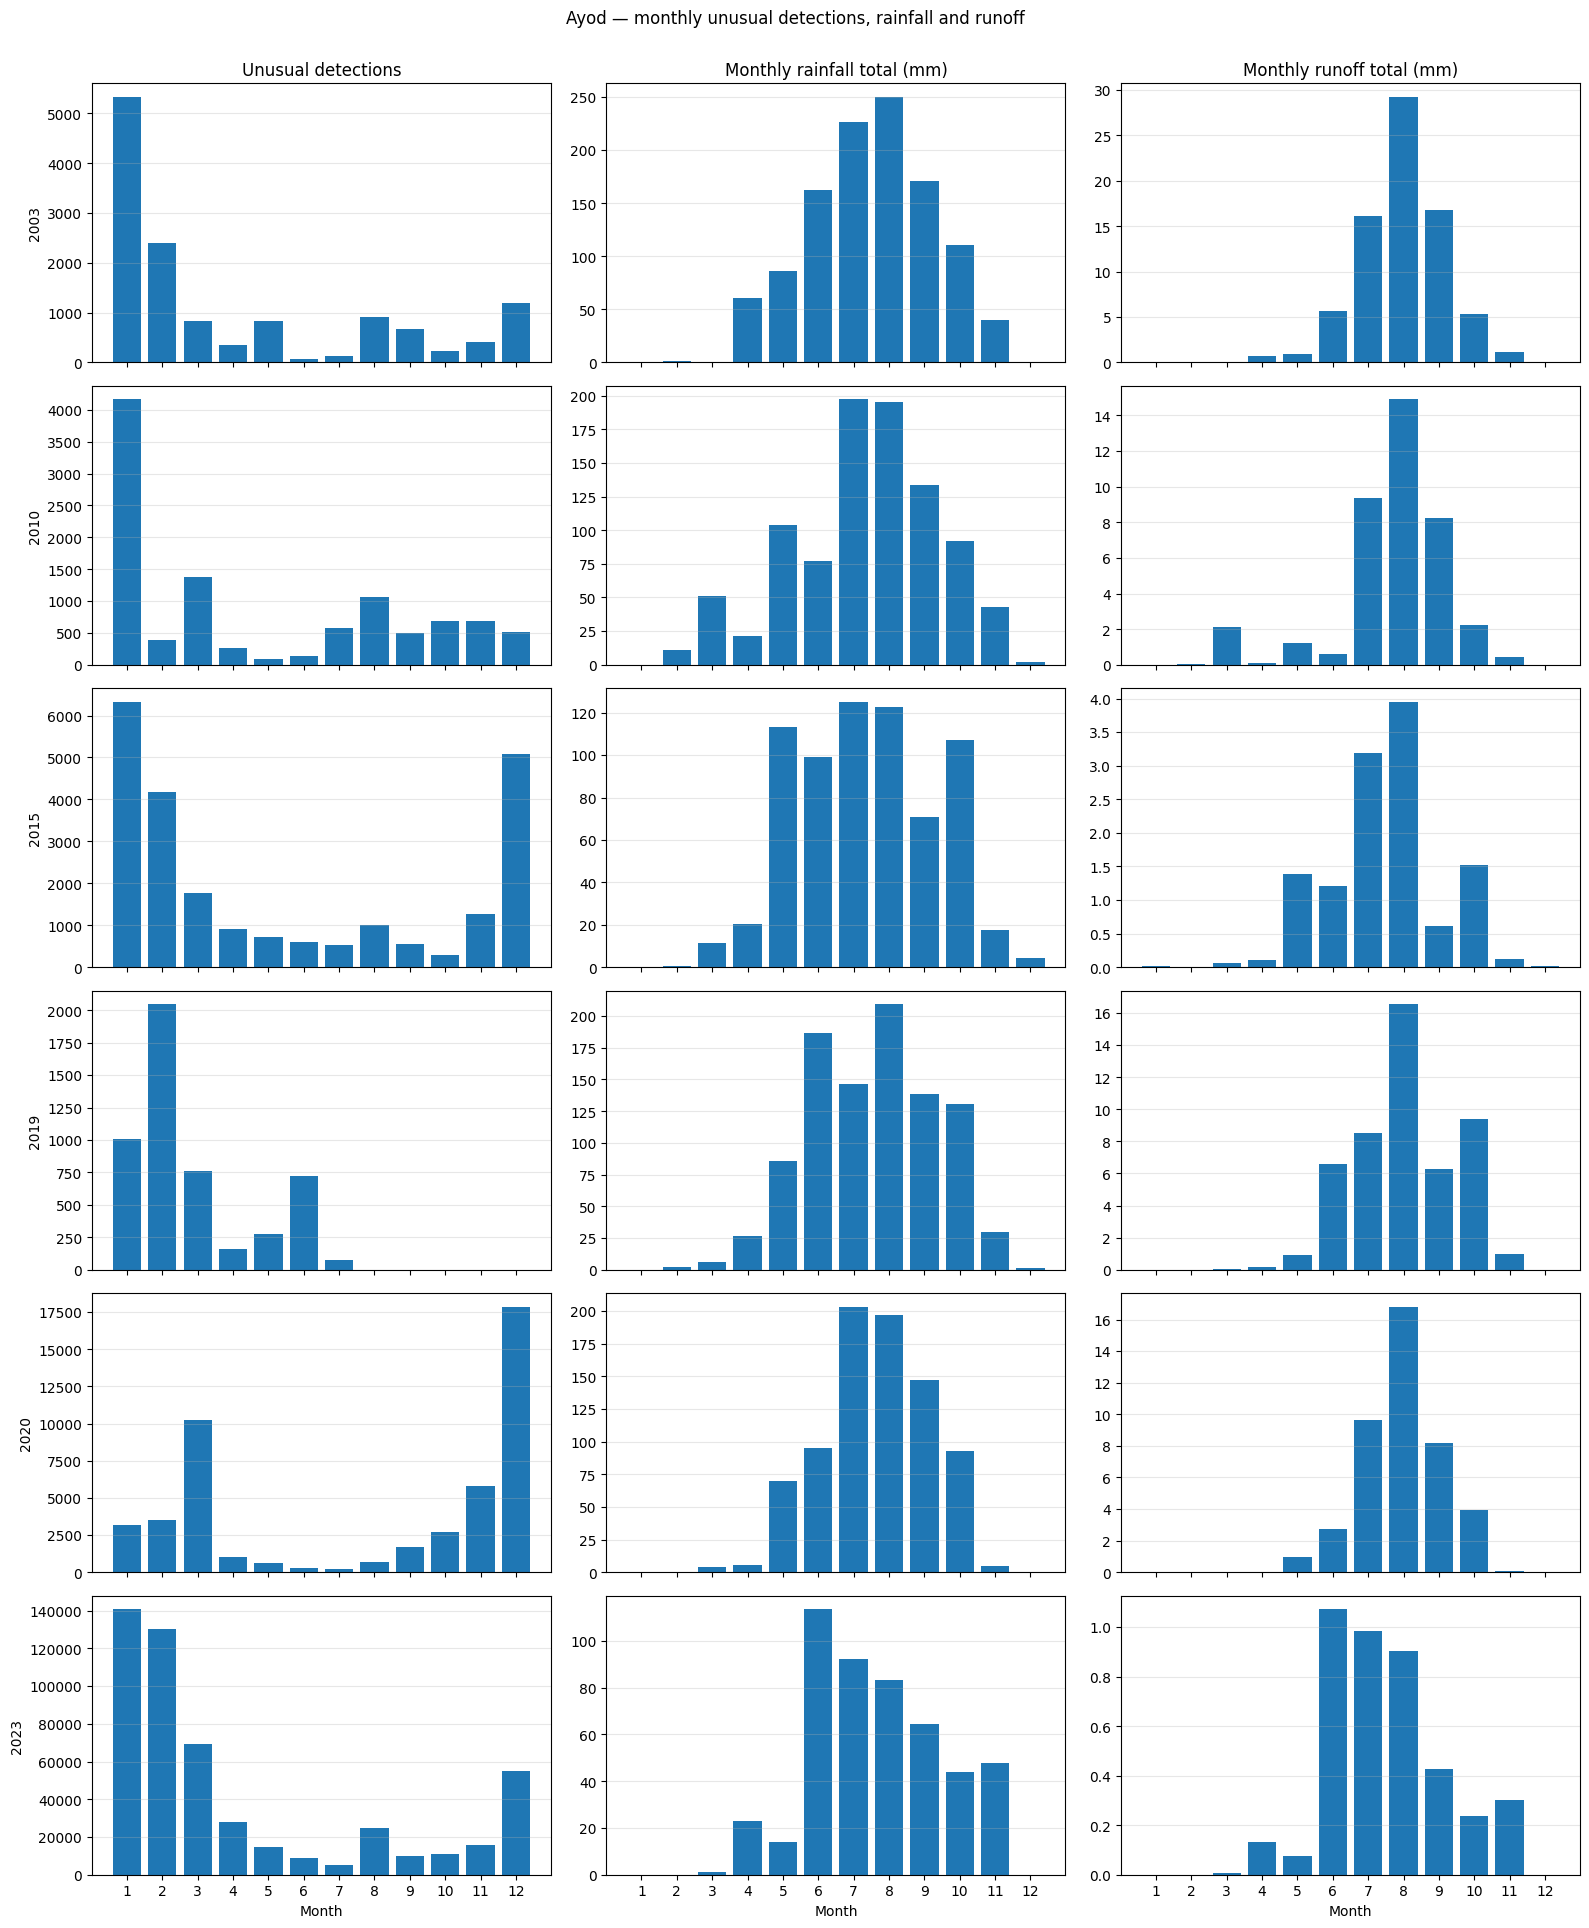

In [24]:
fig, axes = plt.subplots(
    len(YEARS_TO_COMPARE), 3,
    figsize=(16, 3.2 * len(YEARS_TO_COMPARE)),
    sharex=True
)

for row, year in enumerate(YEARS_TO_COMPARE):
    monthly = monthly_by_year[year]

    axes[row, 0].bar(
        monthly.index, monthly["unusual_detections"]
    )
    axes[row, 0].set_ylabel(str(year))
    axes[row, 0].set_title("Unusual detections" if row == 0 else "")
    axes[row, 0].grid(True, axis="y", alpha=0.3)

    axes[row, 1].bar(
        monthly.index, monthly["rainfall_mm"]
    )
    axes[row, 1].set_title("Monthly rainfall total (mm)" if row == 0 else "")
    axes[row, 1].grid(True, axis="y", alpha=0.3)

    axes[row, 2].bar(
        monthly.index, monthly["runoff_mm"]
    )
    axes[row, 2].set_title("Monthly runoff total (mm)" if row == 0 else "")
    axes[row, 2].grid(True, axis="y", alpha=0.3)

for ax in axes[-1]:
    ax.set_xticks(range(1, 13))
    ax.set_xlabel("Month")

plt.suptitle("Ayod — monthly unusual detections, rainfall and runoff", y=1.002)
plt.tight_layout()
plt.show()


In [26]:
annual_summary = (
    monthly_all
    .groupby("year")
    .agg(
        annual_unusual_detections=("unusual_detections", "sum"),
        months_with_detections=("unusual_detections", lambda x: (x > 0).sum()),
        annual_rainfall_mm=("rainfall_mm", "sum"),
        annual_runoff_mm=("runoff_mm", "sum")
    )
)

annual_summary["detections_per_1000_mm_rainfall"] = (
    annual_summary["annual_unusual_detections"]
    / annual_summary["annual_rainfall_mm"] * 1000
)

display(annual_summary.round(2))


,annual_unusual_detections,months_with_detections,annual_rainfall_mm,annual_runoff_mm,detections_per_1000_mm_rainfall
year,,,,,
2003,13358,12,1108.55,75.89,12050.03
2010,10459,12,927.45,39.42,11277.13
2015,23226,12,693.30,12.22,33500.52
2019,5053,7,964.22,49.45,5240.53
2020,47803,12,819.26,42.34,58349.05
2023,512113,12,483.00,4.14,1060268.79


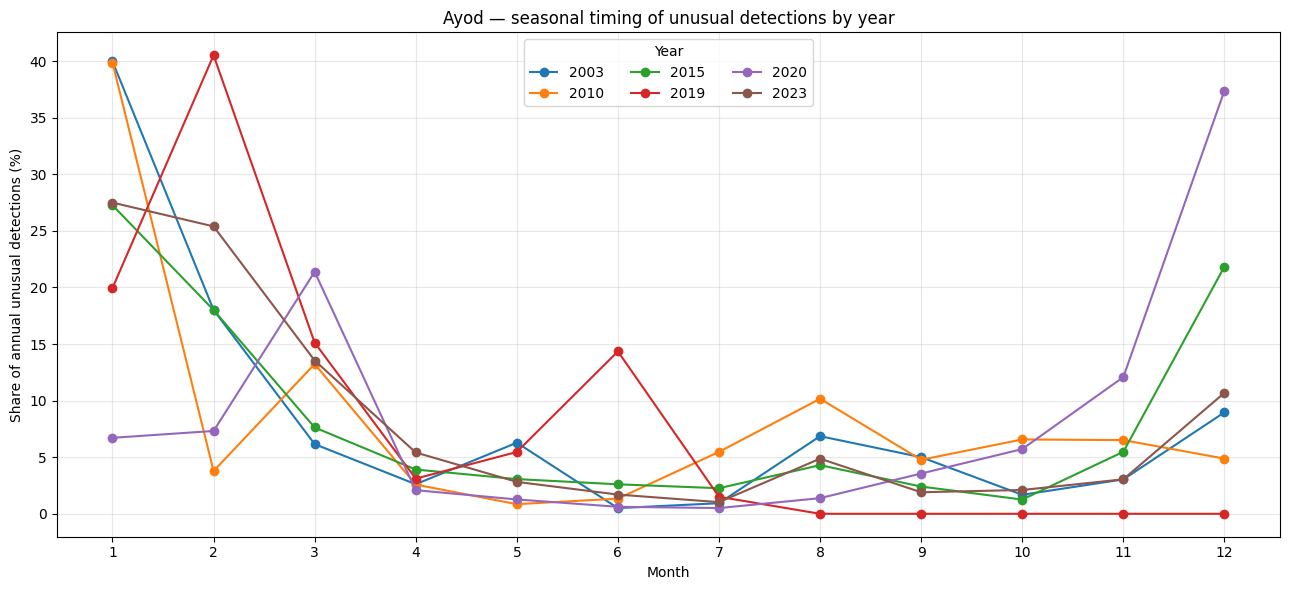

In [27]:
monthly_share = monthly_all.copy()

annual_totals = monthly_share.groupby("year")["unusual_detections"].transform("sum")
monthly_share["share_of_annual_detections"] = (
    monthly_share["unusual_detections"] / annual_totals
)

fig, ax = plt.subplots(figsize=(13, 6))

for year in YEARS_TO_COMPARE:
    subset = monthly_share[monthly_share["year"] == year]
    ax.plot(
        subset["month"],
        subset["share_of_annual_detections"] * 100,
        marker="o",
        label=str(year)
    )

ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Share of annual unusual detections (%)")
ax.set_title("Ayod — seasonal timing of unusual detections by year")
ax.grid(True, alpha=0.3)
ax.legend(title="Year", ncol=3)
plt.tight_layout()
plt.show()


In [28]:
def monthly_flood_categories_for_year(year):
    """Count recurring and unusual detections inside Ayod by month."""

    flood = load_flood_masks(np.array([year]))

    # Filter to Ayod's bounding box
    minx, miny, maxx, maxy = ayod.total_bounds

    flood_near_ayod = flood.loc[
        flood["lon"].between(minx, maxx)
        & flood["lat"].between(miny, maxy)
    ].copy()

    points = gpd.GeoDataFrame(
        flood_near_ayod,
        geometry=gpd.points_from_xy(
            flood_near_ayod["lon"],
            flood_near_ayod["lat"]
        ),
        crs="EPSG:4326"
    )

    inside = gpd.sjoin(
        points,
        ayod[["adm2_name", "geometry"]],
        how="inner",
        predicate="within"
    )

    inside["date"] = pd.to_datetime(inside["date"])
    inside["month"] = inside["date"].dt.month

    monthly = (
        inside.groupby(["month", "flood_type"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=range(1, 13), columns=[0, 1], fill_value=0)
        .rename(columns={
            0: "recurring_detections",
            1: "unusual_detections"
        })
    )

    monthly["year"] = year
    return monthly


category_monthly = {
    year: monthly_flood_categories_for_year(year)
    for year in YEARS_TO_COMPARE
}

category_all = pd.concat(
    category_monthly.values(),
    names=["year", "month"]
).reset_index()

display(category_all.head(15))


flood_type,month,recurring_detections,unusual_detections,year
0,1,3739,5339,2003
1,2,1712,2406,2003
2,3,335,822,2003
3,4,512,349,2003
4,5,350,839,2003
5,6,98,67,2003
6,7,80,125,2003
7,8,123,916,2003
8,9,294,668,2003
9,10,449,224,2003


flood_type,recurring_detections,unusual_detections,unusual_share
year,,,
2003,11721,13358,0.5326
2010,7468,10459,0.5834
2015,26323,23226,0.4687
2019,10907,5053,0.3166
2020,23517,47803,0.6703
2023,41088,512113,0.9257


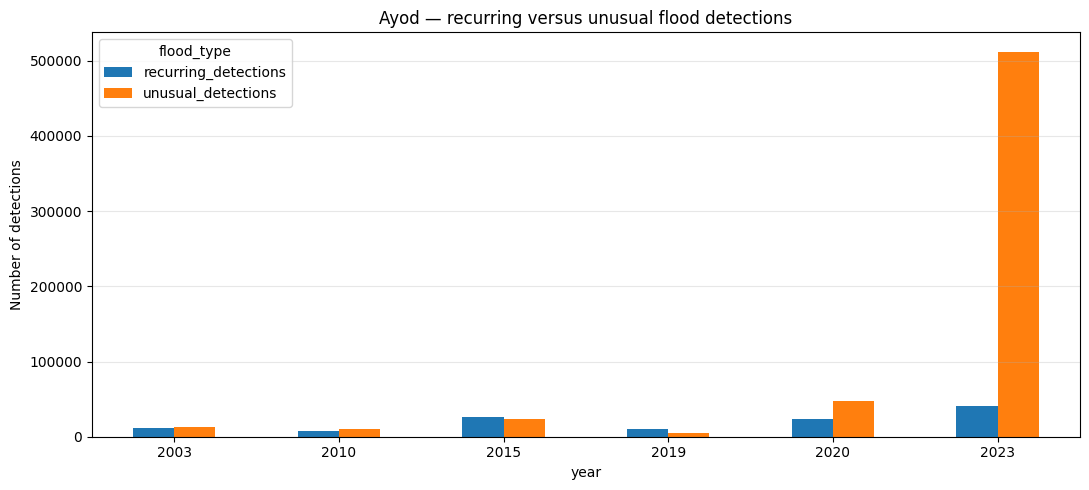

In [29]:
category_annual = (
    category_all.groupby("year")[
        ["recurring_detections", "unusual_detections"]
    ].sum()
)

category_annual["unusual_share"] = (
    category_annual["unusual_detections"]
    / (
        category_annual["recurring_detections"]
        + category_annual["unusual_detections"]
    )
)

display(category_annual.round(4))

category_annual[
    ["recurring_detections", "unusual_detections"]
].plot(
    kind="bar",
    figsize=(11, 5)
)

plt.ylabel("Number of detections")
plt.title("Ayod — recurring versus unusual flood detections")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


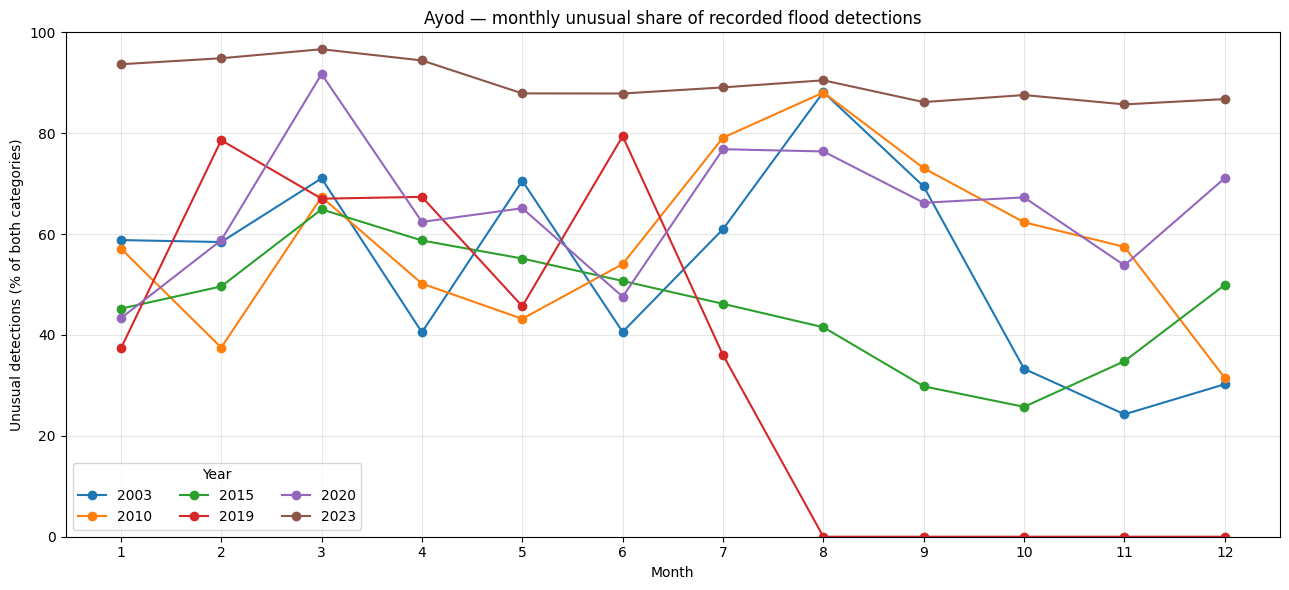

flood_type,year,month,recurring_detections,unusual_detections,unusual_share
36,2019,1,1693,1008,0.373
37,2019,2,557,2047,0.786
38,2019,3,376,764,0.670
39,2019,4,76,157,0.674
40,2019,5,328,276,0.457
41,2019,6,188,725,0.794
42,2019,7,135,76,0.360
43,2019,8,118,0,0.000
44,2019,9,391,0,0.000
45,2019,10,268,0,0.000


In [30]:
# Compare the unusual share month by month for each selected year
category_all["total_detections"] = (
    category_all["recurring_detections"]
    + category_all["unusual_detections"]
)

category_all["unusual_share"] = (
    category_all["unusual_detections"]
    / category_all["total_detections"].replace(0, np.nan)
)

fig, ax = plt.subplots(figsize=(13, 6))

for year in YEARS_TO_COMPARE:
    subset = category_all[category_all["year"] == year].sort_values("month")
    ax.plot(
        subset["month"],
        subset["unusual_share"] * 100,
        marker="o",
        label=str(year)
    )

ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Unusual detections (% of both categories)")
ax.set_title("Ayod — monthly unusual share of recorded flood detections")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend(title="Year", ncol=3)
plt.tight_layout()
plt.show()

display(
    category_all.loc[
        category_all["year"].isin([2019, 2020, 2023]),
        ["year", "month", "recurring_detections",
         "unusual_detections", "unusual_share"]
    ].round(3)
)


## Inspecting original parquet files

In [31]:

from pathlib import Path

raw_root = PROJECT_ROOT / "raw_data" / "flood_masks"

for category in ["compact_recurring", "compact_unusual"]:
    folder = raw_root / category
    print(f"\n{category}")
    print("Folder exists:", folder.exists())

    if folder.exists():
        for year in [2019, 2020, 2023]:
            files = sorted(folder.glob(f"*{year}*.parquet"))
            print(f"{year}: {len(files)} matching files")
            for file in files:
                print("  ", file.name)



compact_recurring
Folder exists: True
2019: 2 matching files
   flood_events_h20v08_2019.parquet
   flood_events_h21v08_2019.parquet
2020: 2 matching files
   flood_events_h20v08_2020.parquet
   flood_events_h21v08_2020.parquet
2023: 2 matching files
   flood_events_h20v08_2023.parquet
   flood_events_h21v08_2023.parquet

compact_unusual
Folder exists: True
2019: 2 matching files
   flood_events_h20v08_2019.parquet
   flood_events_h21v08_2019.parquet
2020: 2 matching files
   flood_events_h20v08_2020.parquet
   flood_events_h21v08_2020.parquet
2023: 2 matching files
   flood_events_h20v08_2023.parquet
   flood_events_h21v08_2023.parquet


In [33]:
inspection_rows = []

for category in ["compact_recurring", "compact_unusual"]:
    folder = raw_root / category

    for year in [2019, 2020, 2023]:
        files = sorted(folder.glob(f"*{year}*.parquet"))

        for file in files:
            df = pd.read_parquet(file)

            dates = pd.to_datetime(df["date"].astype(str), errors="coerce")
            inspection_rows.append({
                "category_folder": category,
                "year": year,
                "file": file.name,
                "rows": len(df),
                "unique_dates": dates.nunique(),
                "first_date": dates.min(),
                "last_date": dates.max(),
                "unique_tiles": df["tile"].nunique() if "tile" in df.columns else None,
                "columns": ", ".join(df.columns)
            })

file_inspection = pd.DataFrame(inspection_rows)
display(file_inspection)


,category_folder,year,file,rows,unique_dates,first_date,last_date,unique_tiles,columns
0,compact_recurring,2019,flood_events_h20v08_2019.parquet,134844,340,2019-01-01,2019-12-31,1,"date, lat, lon, tile, cloud_frac"
1,compact_recurring,2019,flood_events_h21v08_2019.parquet,822835,362,2019-01-01,2019-12-31,1,"date, lat, lon, tile, cloud_frac"
2,compact_recurring,2020,flood_events_h20v08_2020.parquet,373910,335,2020-01-01,2020-12-31,1,"date, lat, lon, tile, cloud_frac"
3,compact_recurring,2020,flood_events_h21v08_2020.parquet,1285618,363,2020-01-01,2020-12-31,1,"date, lat, lon, tile, cloud_frac"
4,compact_recurring,2023,flood_events_h20v08_2023.parquet,307809,351,2023-01-02,2023-12-31,1,"date, lat, lon, tile, cloud_frac"
5,compact_recurring,2023,flood_events_h21v08_2023.parquet,1223908,361,2023-01-02,2023-12-31,1,"date, lat, lon, tile, cloud_frac"
6,compact_unusual,2019,flood_events_h20v08_2019.parquet,383237,324,2019-01-01,2019-12-31,1,"date, lat, lon, tile, cloud_frac"
7,compact_unusual,2019,flood_events_h21v08_2019.parquet,136407,215,2019-01-01,2019-08-05,1,"date, lat, lon, tile, cloud_frac"
8,compact_unusual,2020,flood_events_h20v08_2020.parquet,479356,321,2020-01-01,2020-12-31,1,"date, lat, lon, tile, cloud_frac"
9,compact_unusual,2020,flood_events_h21v08_2020.parquet,2626160,363,2020-01-01,2020-12-31,1,"date, lat, lon, tile, cloud_frac"


In [34]:
daily_source_rows = []

for category in ["compact_recurring", "compact_unusual"]:
    folder = raw_root / category

    for year in [2019, 2020, 2023]:
        files = sorted(folder.glob(f"*{year}*.parquet"))

        for file in files:
            df = pd.read_parquet(file)
            df["date"] = pd.to_datetime(df["date"])

            counts = df.groupby("date").size()

            for date, count in counts.items():
                daily_source_rows.append({
                    "category_folder": category,
                    "year": year,
                    "tile": df["tile"].iloc[0] if "tile" in df.columns else file.stem,
                    "date": date,
                    "detections": int(count)
                })

source_daily = pd.DataFrame(daily_source_rows)

source_daily_summary = (
    source_daily
    .groupby(["category_folder", "year", "tile"])
    .agg(
        total_detections=("detections", "sum"),
        dates_with_detections=("date", "nunique"),
        median_detections_per_date=("detections", "median"),
        max_detections_per_date=("detections", "max")
    )
    .reset_index()
)

display(source_daily_summary)


,category_folder,year,tile,total_detections,dates_with_detections,median_detections_per_date,max_detections_per_date
0,compact_recurring,2019,h20v08,134844,340,67.0,5294
1,compact_recurring,2019,h21v08,822835,362,2044.0,7438
2,compact_recurring,2020,h20v08,373910,335,202.0,10056
3,compact_recurring,2020,h21v08,1285618,363,3086.0,11814
4,compact_recurring,2023,h20v08,307809,351,151.0,6257
5,compact_recurring,2023,h21v08,1223908,361,3119.0,10174
6,compact_unusual,2019,h20v08,383237,324,45.5,9952
7,compact_unusual,2019,h21v08,136407,215,419.0,3655
8,compact_unusual,2020,h20v08,479356,321,356.0,13854
9,compact_unusual,2020,h21v08,2626160,363,3211.0,37501


In [35]:
unusual_source = source_daily[
    source_daily["category_folder"] == "compact_unusual"
].copy()

unusual_source["month"] = unusual_source["date"].dt.month

display(
    unusual_source
    .groupby(["year", "tile", "month"], as_index=False)
    .agg(
        detections=("detections", "sum"),
        dates_with_detections=("date", "nunique")
    )
    .query("year in [2019, 2020, 2023]")
)


,year,tile,month,detections,dates_with_detections
0,2019,h20v08,1,5044,30
1,2019,h20v08,2,465,18
2,2019,h20v08,3,342,24
3,2019,h20v08,4,470,28
4,2019,h20v08,5,517,26
...,...,...,...,...,...
63,2023,h21v08,8,308745,31
64,2023,h21v08,9,162355,30
65,2023,h21v08,10,216105,31
66,2023,h21v08,11,338774,30


In [36]:
# Compare the two source categories for h21v08 in the second half of 2019
year = 2019
tile = "h21v08"

late_2019_rows = []

for category in ["compact_recurring", "compact_unusual"]:
    file_path = (
        PROJECT_ROOT
        / "raw_data"
        / "flood_masks"
        / category
        / f"flood_events_{tile}_{year}.parquet"
    )

    df = pd.read_parquet(file_path)
    df["date"] = pd.to_datetime(df["date"].astype(str), errors="coerce")

    df = df.loc[
        df["date"].between("2019-07-01", "2019-12-31")
    ]

    counts = df.groupby(df["date"].dt.to_period("M")).size()

    for month in range(7, 13):
        period = pd.Period(f"2019-{month:02d}", freq="M")
        late_2019_rows.append({
            "category": category,
            "month": month,
            "detections": int(counts.get(period, 0))
        })

late_2019_check = pd.DataFrame(late_2019_rows)

display(
    late_2019_check.pivot(
        index="month",
        columns="category",
        values="detections"
    )
)


category,compact_recurring,compact_unusual
month,,
7,42791,6590
8,47439,904
9,39518,0
10,61767,0
11,87372,0
12,137661,0


In [37]:
cloud_rows = []

for year in [2019, 2020, 2023]:
    for tile in ["h20v08", "h21v08"]:
        file_path = (
            PROJECT_ROOT
            / "raw_data"
            / "flood_masks"
            / "compact_unusual"
            / f"flood_events_{tile}_{year}.parquet"
        )

        df = pd.read_parquet(file_path)

        cloud_rows.append({
            "year": year,
            "tile": tile,
            "rows": len(df),
            "cloud_frac_unique_values": df["cloud_frac"].nunique(),
            "cloud_frac_min": df["cloud_frac"].min(),
            "cloud_frac_max": df["cloud_frac"].max(),
            "cloud_frac_missing": int(df["cloud_frac"].isna().sum())
        })

display(pd.DataFrame(cloud_rows))


,year,tile,rows,cloud_frac_unique_values,cloud_frac_min,cloud_frac_max,cloud_frac_missing
0,2019,h20v08,383237,1,0.0,0.0,0
1,2019,h21v08,136407,1,0.0,0.0,0
2,2020,h20v08,479356,1,0.0,0.0,0
3,2020,h21v08,2626160,1,0.0,0.0,0
4,2023,h20v08,8612689,1,0.0,0.0,0
5,2023,h21v08,5502608,1,0.0,0.0,0


In [38]:
# Compare daily unusual detections for 2019, 2020 and 2023 by tile
daily_tile_rows = []

for year in [2019, 2020, 2023]:
    for tile in ["h20v08", "h21v08"]:
        file_path = (
            PROJECT_ROOT
            / "raw_data"
            / "flood_masks"
            / "compact_unusual"
            / f"flood_events_{tile}_{year}.parquet"
        )

        df = pd.read_parquet(file_path)
        df["date"] = pd.to_datetime(
            df["date"].astype(str), errors="coerce"
        )

        counts = df.groupby("date").size()

        daily_tile_rows.append({
            "year": year,
            "tile": tile,
            "daily_counts": counts
        })

# Summarise daily counts per year and tile
daily_tile_summary = []

for item in daily_tile_rows:
    counts = item["daily_counts"]

    daily_tile_summary.append({
        "year": item["year"],
        "tile": item["tile"],
        "dates_with_detections": len(counts),
        "median_daily_detections": counts.median(),
        "90th_percentile_daily_detections": counts.quantile(0.90),
        "99th_percentile_daily_detections": counts.quantile(0.99),
        "maximum_daily_detections": counts.max(),
        "total_detections": counts.sum()
    })

display(pd.DataFrame(daily_tile_summary).round(1))


,year,tile,dates_with_detections,median_daily_detections,90th_percentile_daily_detections,99th_percentile_daily_detections,maximum_daily_detections,total_detections
0,2019,h20v08,324,45.5,5296.4,7864.1,9952,383237
1,2019,h21v08,215,419.0,1424.6,3339.3,3655,136407
2,2020,h20v08,321,356.0,4270.0,9524.0,13854,479356
3,2020,h21v08,363,3211.0,21097.2,33750.7,37501,2626160
4,2023,h20v08,357,25580.0,47096.0,56088.5,60671,8612689
5,2023,h21v08,362,10188.0,34930.5,54723.4,69043,5502608


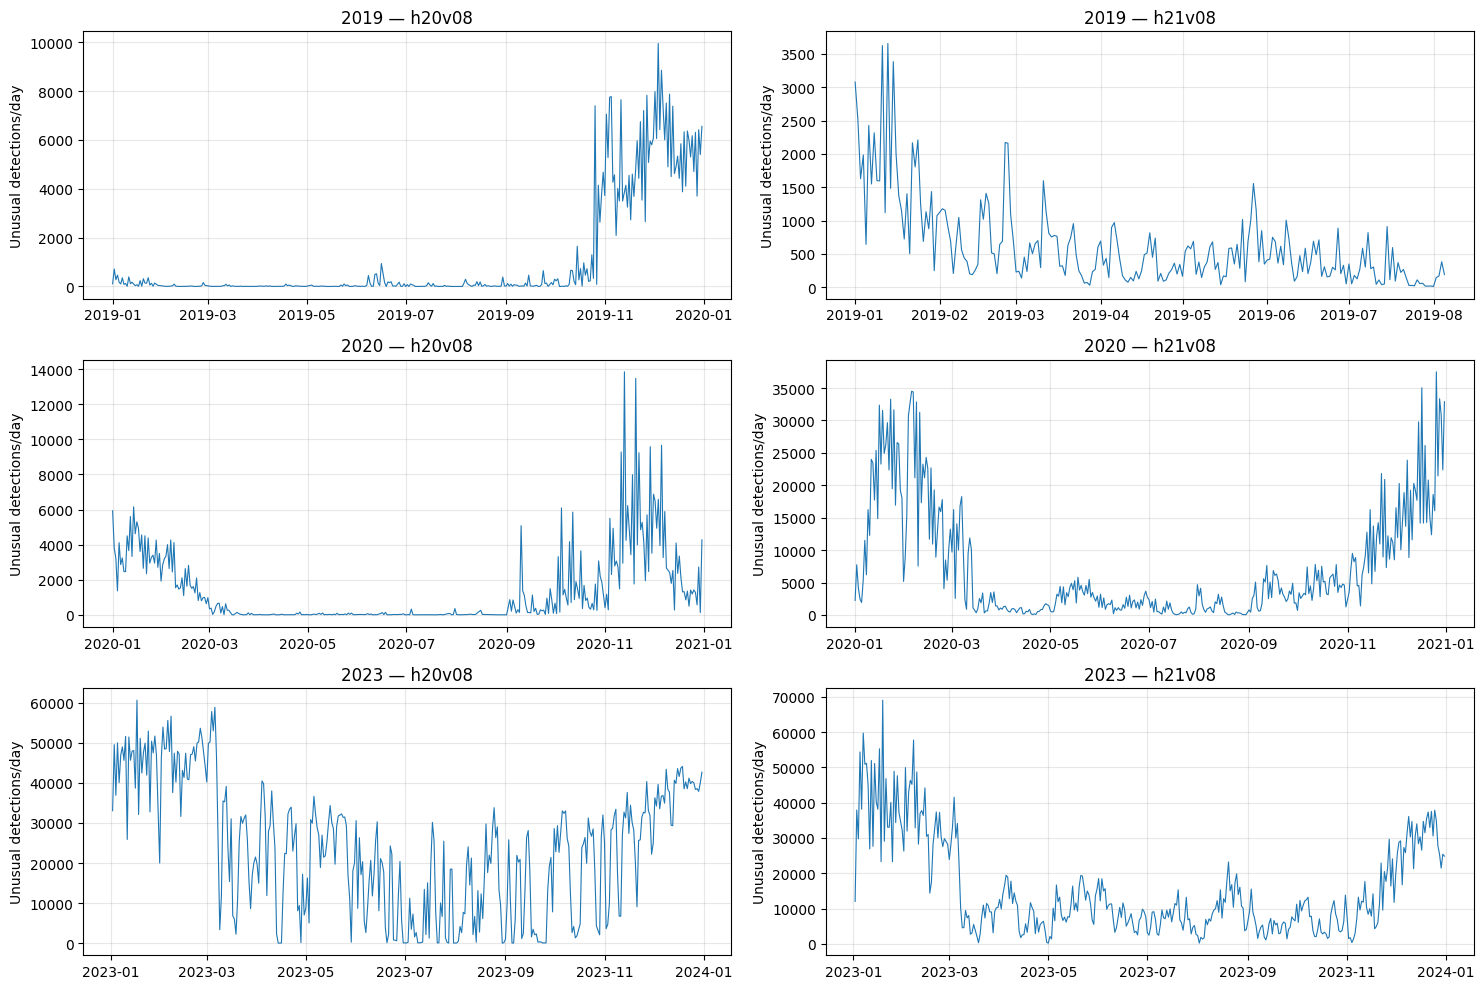

In [40]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))

for row, year in enumerate([2019, 2020, 2023]):
    for col, tile in enumerate(["h20v08", "h21v08"]):
        item = next(
            x for x in daily_tile_rows
            if x["year"] == year and x["tile"] == tile
        )

        counts = item["daily_counts"].sort_index()

        axes[row, col].plot(counts.index, counts.values, linewidth=0.8)
        axes[row, col].set_title(f"{year} — {tile}")
        axes[row, col].set_ylabel("Unusual detections/day")
        axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [41]:
# Create a dedicated folder for dashboard-ready analysis outputs
dashboard_data_dir = PROJECT_ROOT / "processed_data" / "dashboard"
dashboard_data_dir.mkdir(parents=True, exist_ok=True)

# 1. Daily Ayod weather and unusual-detection analysis for 2020
daily_output = lag_data.copy()
daily_output.index.name = "date"
daily_output = daily_output.reset_index()

daily_output.to_csv(
    dashboard_data_dir / "ayod_daily_analysis_2020.csv",
    index=False
)

# 2. Monthly weather and unusual-detection summaries
monthly_output = monthly_all.copy()
monthly_output.to_csv(
    dashboard_data_dir / "ayod_monthly_comparison.csv",
    index=False
)

# 3. Lag-correlation results for Ayod, 2020
lag_results.to_csv(
    dashboard_data_dir / "ayod_lag_correlations_2020.csv",
    index=False
)

# 4. Seasonal lag-correlation comparison
seasonal_check.to_csv(
    dashboard_data_dir / "ayod_seasonal_lag_correlations_2020.csv",
    index=False
)

# 5. Monthly recurring/unusual category comparison
category_all.to_csv(
    dashboard_data_dir / "ayod_monthly_flood_categories.csv",
    index=False
)

print("Dashboard output files created:")
for path in sorted(dashboard_data_dir.glob("*.csv")):
    print(f"{path.name}: {path.stat().st_size / 1024:.1f} KB")


Dashboard output files created:
ayod_daily_analysis_2020.csv: 65.3 KB
ayod_lag_correlations_2020.csv: 3.6 KB
ayod_monthly_comparison.csv: 6.6 KB
ayod_monthly_flood_categories.csv: 2.9 KB
ayod_seasonal_lag_correlations_2020.csv: 1.6 KB


In [42]:
# Find the administrative polygons corresponding to the three dashboard areas
target_names = ["Raja", "Malakal", "Bor"]

for target in target_names:
    matches = admin2[
        admin2["adm2_name"].str.contains(target, case=False, na=False)
    ]

    print(f"\nMatches for {target}:")
    display(matches[["adm2_name", "geometry"]].drop(columns="geometry"))



Matches for Raja:


,adm2_name
67,Raja



Matches for Malakal:


,adm2_name
53,Malakal



Matches for Bor:


,adm2_name
16,Bor South
21,Pibor


In [44]:
from shapely.geometry import box

dashboard_areas = ["Raja", "Malakal", "Bor South"]

# Load the administrative boundaries if needed
admin2_path = (
    PROJECT_ROOT / "raw_data" / "Administrative boundaries" / "ssd_admin2.geojson"
)
admin2 = gpd.read_file(admin2_path)

# Approximate geographic footprint of the two currently loaded tiles.
# These are tile bounds, not a measure of valid satellite observations.
tile_footprint = gpd.GeoDataFrame(
    {"tile": ["h20v08", "h21v08"]},
    geometry=[
        box(20, 0, 30, 10),
        box(30, 0, 40, 10)
    ],
    crs="EPSG:4326"
)

area_crs = "EPSG:6933"
admin2_projected = admin2.to_crs(area_crs)
tiles_projected = tile_footprint.to_crs(area_crs)

coverage_rows = []

for _, area in admin2_projected[
    admin2_projected["adm2_name"].isin(dashboard_areas)
].iterrows():

    area_geom = area.geometry
    area_km2 = area_geom.area / 1e6

    # Union avoids double-counting overlapping tile footprints
    covered_geom = tiles_projected.geometry.union_all().intersection(area_geom)
    covered_km2 = covered_geom.area / 1e6

    coverage_rows.append({
        "adm2_name": area["adm2_name"],
        "area_sqkm": area_km2,
        "approx_covered_sqkm": covered_km2,
        "approx_coverage_pct": 100 * covered_km2 / area_km2
    })

coverage_check = pd.DataFrame(coverage_rows).sort_values("adm2_name")
display(coverage_check.round(2))


,adm2_name,area_sqkm,approx_covered_sqkm,approx_coverage_pct
0,Bor South,13962.84,13962.84,100.00
1,Malakal,754.68,754.68,100.00
2,Raja,62010.57,57719.58,93.08


In [45]:
dashboard_areas = ["Raja", "Malakal", "Bor South"]

area_lookup = (
    admin2.loc[
        admin2["adm2_name"].isin(dashboard_areas),
        ["adm2_name", "geometry"]
    ]
    .copy()
)

area_lookup["area_sqkm"] = (
    area_lookup.to_crs("EPSG:6933").geometry.area / 1e6
)

display(
    area_lookup[["adm2_name", "area_sqkm"]]
    .sort_values("adm2_name")
    .reset_index(drop=True)
)

assert set(area_lookup["adm2_name"]) == set(dashboard_areas)


,adm2_name,area_sqkm
0,Bor South,13962.835622
1,Malakal,754.680410
2,Raja,62010.568725


In [50]:
YEAR = 2020
dashboard_areas = ["Bor South", "Malakal", "Ayod"]

# Load the flood detections for the pilot year
flood = load_flood_masks(np.array([YEAR]))
flood["date"] = pd.to_datetime(flood["date"].astype(str), errors="coerce")

# Select the three study areas and use a projected CRS for geometry operations
areas = admin2.loc[
    admin2["adm2_name"].isin(dashboard_areas),
    ["adm2_name", "geometry", "area_sqkm"]
].copy()

if "area_sqkm" not in areas.columns:
    areas["area_sqkm"] = areas.to_crs("EPSG:6933").geometry.area / 1e6

# Create flood point geometries
flood_points = gpd.GeoDataFrame(
    flood,
    geometry=gpd.points_from_xy(flood["lon"], flood["lat"]),
    crs="EPSG:4326"
)

# Spatially limit points to the combined bounds of the selected areas
combined_bounds = areas.total_bounds
minx, miny, maxx, maxy = combined_bounds

flood_points = flood_points.cx[minx:maxx, miny:maxy]

# Assign points to administrative areas
flood_joined = gpd.sjoin(
    flood_points,
    areas[["adm2_name", "geometry"]],
    how="inner",
    predicate="within"
)

# Count detections per area and date
daily_flood = (
    flood_joined
    .groupby(["adm2_name", "date"])
    .agg(
        flood_detections=("flood_type", "size"),
        recurring_detections=("flood_type", lambda x: (x == 0).sum()),
        unusual_detections=("flood_type", lambda x: (x == 1).sum())
    )
    .reset_index()
)

daily_flood["year"] = YEAR
daily_flood["month"] = daily_flood["date"].dt.month

print("Rows:", len(daily_flood))
print("Areas represented:", sorted(daily_flood["adm2_name"].unique()))
display(daily_flood.groupby("adm2_name").agg(
    days_with_detections=("date", "nunique"),
    total_detections=("flood_detections", "sum"),
    recurring_detections=("recurring_detections", "sum"),
    unusual_detections=("unusual_detections", "sum")
))


Rows: 524
Areas represented: ['Ayod', 'Bor South', 'Malakal']


,days_with_detections,total_detections,recurring_detections,unusual_detections
adm2_name,,,,
Ayod,253,71320,23517,47803
Bor South,243,47622,12008,35614
Malakal,28,126,8,118


In [51]:
# Diagnose the flood-point distribution for the three study areas
diagnostic_rows = []

for _, area in areas.iterrows():
    name = area["adm2_name"]
    geom = area.geometry

    # Points inside the area's bounding box
    minx, miny, maxx, maxy = geom.bounds
    in_bbox = flood_points.cx[minx:maxx, miny:maxy]

    # Points assigned to the actual polygon
    assigned = flood_joined[flood_joined["adm2_name"] == name]

    diagnostic_rows.append({
        "adm2_name": name,
        "points_in_bbox": len(in_bbox),
        "points_assigned_to_polygon": len(assigned),
        "dates_with_detections": assigned["date"].nunique(),
        "assignment_pct_of_bbox_points": (
            100 * len(assigned) / len(in_bbox) if len(in_bbox) else np.nan
        )
    })

display(pd.DataFrame(diagnostic_rows).round(2))

,adm2_name,points_in_bbox,points_assigned_to_polygon,dates_with_detections,assignment_pct_of_bbox_points
0,Ayod,77223,71320,253,92.36
1,Bor South,91634,47622,243,51.97
2,Malakal,292,126,28,43.15


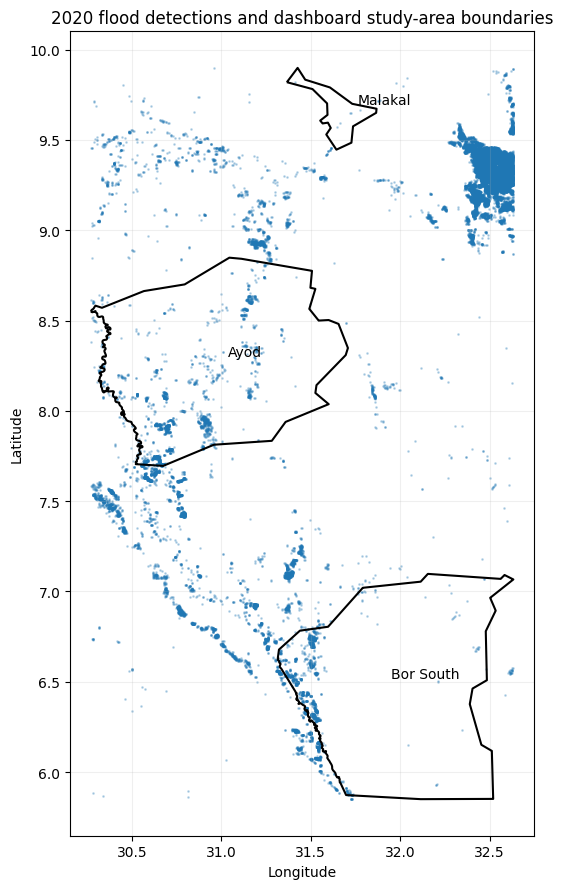

In [52]:
fig, ax = plt.subplots(figsize=(10, 9))

# Plot the three study-area boundaries
areas.boundary.plot(ax=ax, color="black", linewidth=1.5)

# Plot a sample of flood points so the map remains responsive
sample_points = flood_points.sample(
    n=min(30000, len(flood_points)),
    random_state=42
)
sample_points.plot(
    ax=ax,
    markersize=1,
    alpha=0.25
)

for _, area in areas.iterrows():
    point = area.geometry.representative_point()
    ax.annotate(
        area["adm2_name"],
        (point.x, point.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=10
    )

ax.set_title("2020 flood detections and dashboard study-area boundaries")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
